#### Best future price for non-fossil fuel energy

**Which non-fossil fuel energy technology will have the best price in the future?**

To be able to predict prices you'll probably need to use linear regression over the various non-fossil fuel options.

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
from sklearn.linear_model import LinearRegression

In [155]:
# Import the original Levelized Cost of Energy data
# df_original_data = pd.read_csv('https://raw.githubusercontent.com/majavanput/co2-emissions/main/data/levelized-cost-of-energy.csv')
df_original_data = pd.read_csv('../data/levelized-cost-of-energy.csv')

In [156]:
# Print information about the DataFrame
df_original_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 926 entries, 0 to 925
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    926 non-null    str    
 1   Code                      926 non-null    str    
 2   Year                      926 non-null    int64  
 3   Bioenergy                 16 non-null     float64
 4   Geothermal                18 non-null     float64
 5   Offshore wind             26 non-null     float64
 6   Solar photovoltaic        302 non-null    float64
 7   Concentrated solar power  16 non-null     float64
 8   Hydropower                16 non-null     float64
 9   Onshore wind              890 non-null    float64
dtypes: float64(7), int64(1), str(2)
memory usage: 72.5 KB


In [157]:
# Overview of missing values per column
for name, values in df_original_data.items():
  print(f'Missing values in column {name}: ', df_original_data[name].isnull().sum())

# Total number of missing values in dataset
total_nan = df_original_data.isnull().sum().sum()
print(f"Total number of NaN values in the DataFrame: {total_nan}")

Missing values in column Entity:  0
Missing values in column Code:  0
Missing values in column Year:  0
Missing values in column Bioenergy:  910
Missing values in column Geothermal:  908
Missing values in column Offshore wind:  900
Missing values in column Solar photovoltaic:  624
Missing values in column Concentrated solar power:  910
Missing values in column Hydropower:  910
Missing values in column Onshore wind:  36
Total number of NaN values in the DataFrame: 5198


In [158]:
df_cost_energy = df_original_data.copy()

# Drop unnecessary columns
df_cost_energy.drop(columns=['Code'], inplace=True)

In [159]:
df_cost_energy_world = df_cost_energy.copy()

# Use world data for analysis
df_cost_energy_world = df_cost_energy_world[df_cost_energy_world['Entity'] == 'World']

In [160]:
df_cost_energy_world.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 884 to 925
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Entity                    42 non-null     str    
 1   Year                      42 non-null     int64  
 2   Bioenergy                 16 non-null     float64
 3   Geothermal                18 non-null     float64
 4   Offshore wind             26 non-null     float64
 5   Solar photovoltaic        16 non-null     float64
 6   Concentrated solar power  16 non-null     float64
 7   Hydropower                16 non-null     float64
 8   Onshore wind              42 non-null     float64
dtypes: float64(7), int64(1), str(1)
memory usage: 3.1 KB


<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


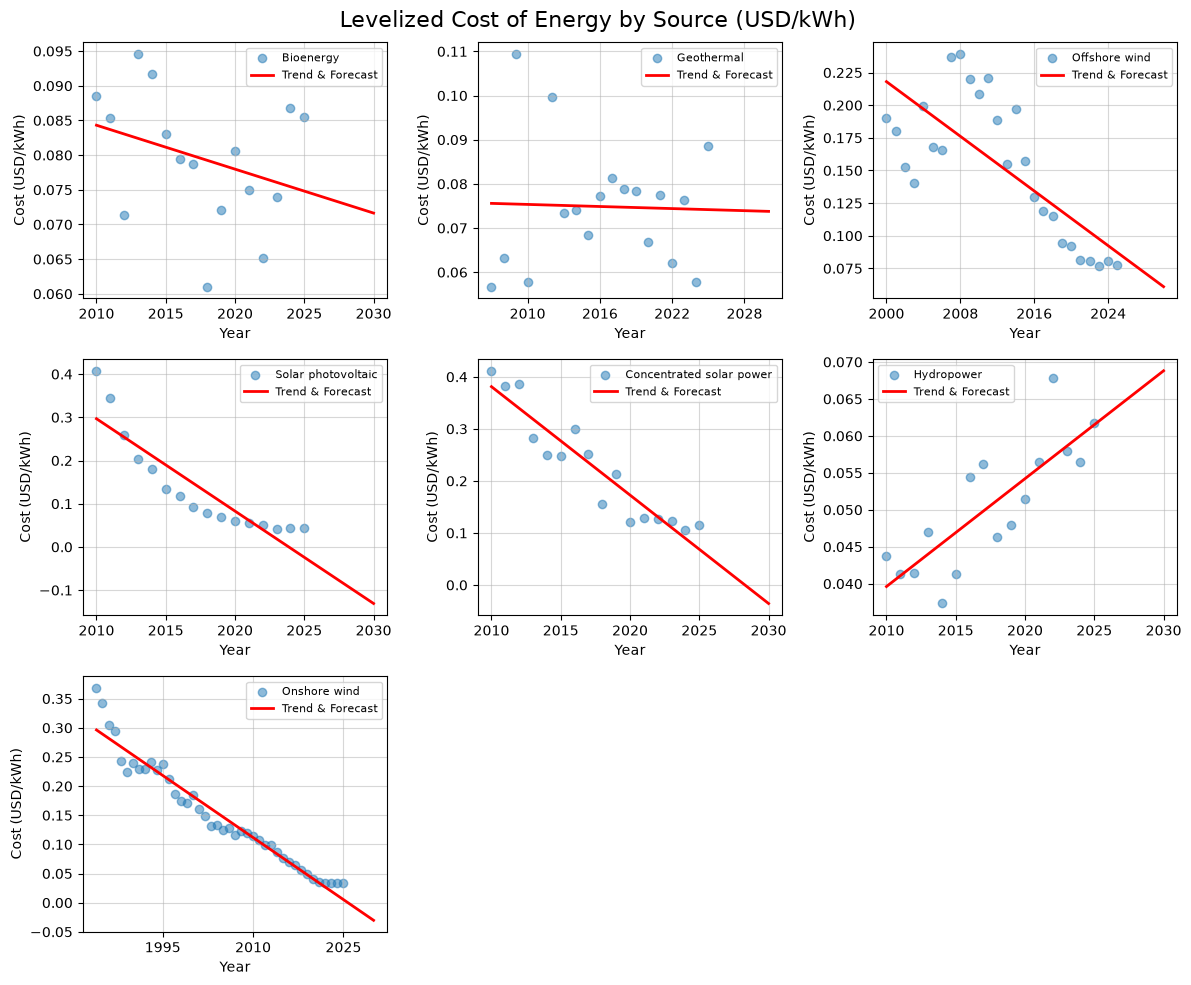

In [ ]:
trend = []
energy_sources = [
    "Bioenergy",
    "Geothermal",
    "Offshore wind",
    "Solar photovoltaic",
    "Concentrated solar power",
    "Hydropower",
    "Onshore wind"
]

# Create a figure and axis object
fig, ax = plt.subplots(3, 3, figsize=(12, 10))

# To access in for loop, flatten the axes array
ax = ax.flatten()

for i, source in enumerate(energy_sources):
    data = df_cost_energy_world[['Year', source]].dropna()

    x = data[['Year']]
    y = data[[source]]
    print(type(y))

    ax[i].scatter(x, y, alpha=0.5, label=source)

    # Set title, labels, legend, grid
    ax[i].set_xlabel('Year')
    ax[i].set_ylabel('Cost (USD/kWh)')
    ax[i].grid(alpha=0.5)

    x_predict = x.values.reshape(-1, 1)
    y_predict = y.values

    model = LinearRegression()
    model.fit(x_predict, y_predict)

    first_year = data['Year'].min()
    last_year = data['Year'].max()
    years = np.arange(first_year, last_year + 6).reshape(-1, 1) # Including 5 years into the future

    prediction = model.predict(years)
    
    # Store historical data and future predictions (5 years past and 5 years future) in the trend list
    for year, cost in zip(years[-10:, 0], prediction[-10:]):
        trend.append({
            'Energy source': source,
            'Year': year,
            'Cost (USD/kWh)': cost
        })

    # Trend and predict values for the regression line
    ax[i].plot(years, prediction, color='red', linewidth=2, label='Trend & Forecast')

    # Set legend
    ax[i].legend(loc='best', fontsize=8)

    # Maximum of 5 ticks on the x-axis
    ax[i].xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5))

df_trend = pd.DataFrame(trend)
df_trend = df_trend.pivot(
  index='Year',
  columns='Energy source',
  values='Cost (USD/kWh)'
)

ax[8].set_visible(False)
ax[7].set_visible(False)
fig.suptitle('Levelized Cost of Energy by Source (USD/kWh)', fontsize=16)
plt.tight_layout()
plt.show()

In [165]:
df_trend

,Energy source,Year,Cost (USD/kWh)
0,Bioenergy,[2021],0.077342
1,Bioenergy,[2022],0.076709
2,Bioenergy,[2023],0.076075
3,Bioenergy,[2024],0.075442
4,Bioenergy,[2025],0.074808
...,...,...,...
65,Onshore wind,[2026],-0.001815
66,Onshore wind,[2027],-0.008915
67,Onshore wind,[2028],-0.016015
68,Onshore wind,[2029],-0.023115


**Which non-fossil fuel energy technology will have the best price in the future?**

Based on the linear regression, solar photovoltaic is predicted to have the lowest cost between 2026 and 2030. However, the model predicts negative costs for concentrated solar power, onshore wind and solar photovoltaic. This also shows the limitations of linear regressions. Solar photovoltaic shows the strongest downward trend, but the predicted values should not be interpreted as realistic future prices.